In [ ]:
# import library
import pandas as pd  #olah data (DataFrame)
import numpy as np  #hitungan numerik
import matplotlib.pyplot as plt  #visualisasi grafik
from sklearn.linear_model import LinearRegression  #model regresi linear
from sklearn.model_selection import train_test_split  #membagi data training & test
from sklearn import metrics  #evaluasi hasil model

In [ ]:
data = {
    'jumlah_iklan': [1, 2, 3, 4, 5, 6, 7, 8],
    'diskon': [5, 10, 10, 15, 15, 20, 20, 25],
    'harga': [100, 95, 90, 85, 80, 75, 70, 65],
    'rating': [3.5, 3.8, 4.0, 4.2, 4.5, 4.6, 4.8, 5.0],
    'penjualan': [100, 150, 200, 270, 350, 430, 520, 620]
}

df = pd.DataFrame(data)
print(df)

   jumlah_iklan  diskon  harga  rating  penjualan
0             1       5    100     3.5        100
1             2      10     95     3.8        150
2             3      10     90     4.0        200
3             4      15     85     4.2        270
4             5      15     80     4.5        350
5             6      20     75     4.6        430
6             7      20     70     4.8        520
7             8      25     65     5.0        620


In [ ]:
X = df[['jumlah_iklan', 'diskon', 'harga', 'rating']] #variabel independen (input)
y = df['penjualan'] #variabel dependen (output)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Data dibagi menjadi:

- 80% training

- 20% testing

random_state=42 agar hasil konsisten

In [ ]:
model = LinearRegression() #membuat model regresi linear
model.fit(X_train, y_train) #melatih model menggunakan data training

LinearRegression()

In [ ]:
# melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_) #nilai dasar saat semua variabel = 0
print("Koefisien (b1, b2, b3, b4):", model.coef_) #pengaruh masing-masing variabel independen terhadap penjualan

# b1 → pengaruh jumlah iklan terhadap penjualan
# b2 → pengaruh diskon terhadap penjualan
# b3 → pengaruh harga terhadap penjualan
# b4 → pengaruh rating terhadap penjualan

Intercept (a): 4453.961538461566
Koefisien (b1, b2, b3, b4): [   6.19230769   -3.4         -30.96153846 -360.        ]


In [ ]:
y_pred = model.predict(X_test) #prediksi data testing

print("Data Testing:")
print(X_test)
print("Penjualan Asli:", y_test.values)
print("Penjualan Prediksi:", y_pred)

Data Testing:
   jumlah_iklan  diskon  harga  rating
1             2      10     95     3.8
5             6      20     75     4.6
Penjualan Asli: [150 430]
Penjualan Prediksi: [123. 445.]


In [ ]:
# evaluasi model regresi
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

MAE: 21.0
MSE: 477.0
RMSE: 21.840329667841555


In [ ]:
# prediksi
prediksi = model.predict([[5, 15, 80, 4.5]])
print("Prediksi penjualan:", prediksi[0])

Prediksi penjualan: 337.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


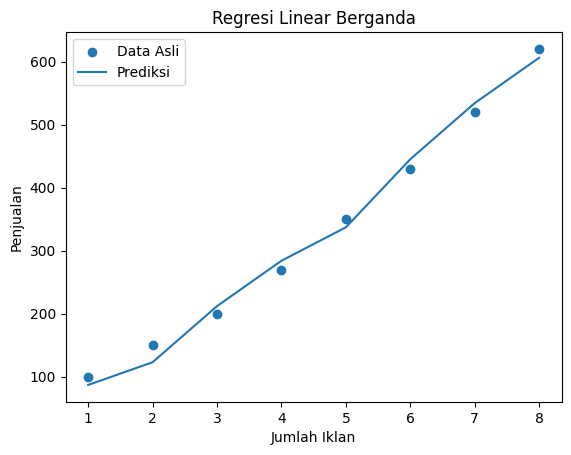

In [ ]:
plt.scatter(df['jumlah_iklan'], y, label="Data Asli") #menampilkan data asli dalam bentuk titik
plt.plot(df['jumlah_iklan'], model.predict(X), label="Prediksi") #menampilkan garis hasil model regresi
plt.xlabel("Jumlah Iklan")
plt.ylabel("Penjualan")
plt.title("Regresi Linear Berganda")
plt.legend()
plt.show()

Hasil analisis menunjukkan bahwa jumlah iklan, diskon, harga, dan rating berpengaruh terhadap penjualan. Secara umum, peningkatan nilai variabel tersebut diikuti dengan peningkatan penjualan, dan model sudah mampu memprediksi dengan cukup baik meskipun data yang digunakan masih sederhana.